# Train INRs for all MNIST images (per-digit warm-starting)

For each digit `0-9` we fit one **base INR** from scratch on that digit's first
image. The base INR then **initializes** (warm-starts) the INRs for every other
image of the same digit, so they converge much faster than training from scratch.

The base INR is cached on disk and reused across runs, so the initialization is
stable and we never retrain it. All the logic lives in `training.py`; this
notebook just wires it together and visualizes the result.

> Run this notebook from the `data_generation/` directory so the `model`,
> `dataset`, and `training` imports resolve (same as `train.py`).

In [9]:
import os

import torch
import matplotlib.pyplot as plt

from dataset import OptimizedDataset
from training import train_all_digits, load_inr, reconstruct, get_device

device = get_device()
print(f"Using device: {device}")

Using device: cpu


## Configuration

- `SAMPLES_PER_DIGIT = None` trains **all** images of each digit (~6000/digit,
  ~60k total). Set it to a small number (e.g. `25`) for a quick smoke test first.
- `DIGITS` selects which digits to process.
- Checkpoints are written to `SAVE_DIR/digit_<d>/sample_<i>.pth`; the cached base
  INR for each digit lives in `BASE_DIR/digit_<d>_base.pth`.

In [10]:
SAMPLES_PER_DIGIT = None      # set to None to train every MNIST image
DIGITS = range(10)

SAVE_DIR = os.path.join("checkpoints", "all_inrs")
BASE_DIR = os.path.join("checkpoints", "base_inrs")

# Training hyperparameters (forwarded to training.train_inr).
TRAIN_KWARGS = dict(lr=1e-3, loss_threshold=0.002, max_epochs=10000)

In [11]:
dataset = OptimizedDataset(as_inr=True)

# The coordinate grid is identical for every image, so compute it once and reuse.
coords = dataset.coordinate_grid().to(device)

counts = {d: len(p) for d, p in dataset.positions_by_label().items()}
print("Available images per digit:", counts)

Available images per digit: {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


## Run the pipeline

This trains every requested INR and returns one record per image (digit, sample
index, epochs to converge, final loss, checkpoint path). Cached base INRs are
loaded instead of retrained.

In [12]:
records = train_all_digits(
    dataset,
    save_dir=SAVE_DIR,
    base_dir=BASE_DIR,
    device=device,
    digits=DIGITS,
    samples_per_digit=SAMPLES_PER_DIGIT,
    coords=coords,
    **TRAIN_KWARGS,
)

print(f"\nTrained {len(records)} INRs total")

=== Digit 0: 5923 images ===
  digit 0: 200/5923 INRs trained
  digit 0: 400/5923 INRs trained
  digit 0: 600/5923 INRs trained
  digit 0: 800/5923 INRs trained
  digit 0: 1000/5923 INRs trained
  digit 0: 1200/5923 INRs trained
  digit 0: 1400/5923 INRs trained
  digit 0: 1600/5923 INRs trained
  digit 0: 1800/5923 INRs trained
  digit 0: 2000/5923 INRs trained
  digit 0: 2200/5923 INRs trained
  digit 0: 2400/5923 INRs trained
  digit 0: 2600/5923 INRs trained
  digit 0: 2800/5923 INRs trained
  digit 0: 3000/5923 INRs trained
  digit 0: 3200/5923 INRs trained
  digit 0: 3400/5923 INRs trained
  digit 0: 3600/5923 INRs trained
  digit 0: 3800/5923 INRs trained
  digit 0: 4000/5923 INRs trained
  digit 0: 4200/5923 INRs trained
  digit 0: 4400/5923 INRs trained
  digit 0: 4600/5923 INRs trained
  digit 0: 4800/5923 INRs trained
  digit 0: 5000/5923 INRs trained
  digit 0: 5200/5923 INRs trained
  digit 0: 5400/5923 INRs trained
  digit 0: 5600/5923 INRs trained
  digit 0: 5800/5923 IN

## Summary of convergence

How many epochs each INR needed, grouped by digit. Base INRs (sample #0) are trained from scratch; the rest are warm-started.

In [13]:
import statistics

for digit in DIGITS:
    rows = [r for r in records if r["digit"] == digit]
    base = next(r for r in rows if r["is_base"])
    warm = [r for r in rows if not r["is_base"]]

    base_desc = "cached" if base["base_cached"] else f"{base['epochs']} epochs"
    if warm:
        warm_epochs = [r["epochs"] for r in warm]
        print(f"digit {digit}: base ({base_desc}) | "
              f"warm-started x{len(warm)} -> epochs "
              f"min={min(warm_epochs)} median={int(statistics.median(warm_epochs))} max={max(warm_epochs)}")
    else:
        print(f"digit {digit}: base ({base_desc}) | no warm-started samples")

digit 0: base (cached) | warm-started x5922 -> epochs min=133 median=517 max=10001
digit 1: base (cached) | warm-started x6741 -> epochs min=13 median=221 max=10001
digit 2: base (cached) | warm-started x5957 -> epochs min=233 median=785 max=10001
digit 3: base (cached) | warm-started x6130 -> epochs min=196 median=669 max=10001
digit 4: base (cached) | warm-started x5841 -> epochs min=245 median=669 max=10001
digit 5: base (cached) | warm-started x5420 -> epochs min=204 median=634 max=10001
digit 6: base (cached) | warm-started x5917 -> epochs min=134 median=545 max=10001
digit 7: base (cached) | warm-started x6264 -> epochs min=88 median=435 max=10001
digit 8: base (cached) | warm-started x5850 -> epochs min=146 median=768 max=10001
digit 9: base (cached) | warm-started x5948 -> epochs min=162 median=565 max=10001


/var/folders/hp/z11qj2dd0y3_cq4fr6_tp8g00000gn/T/ipykernel_75638/245826793.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


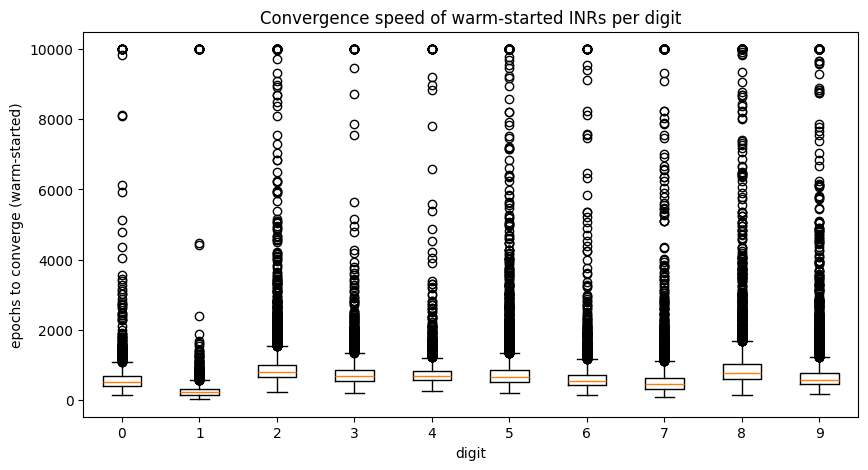

In [14]:
# Distribution of epochs-to-converge for the warm-started INRs, per digit.
warm_by_digit = [
    [r["epochs"] for r in records if r["digit"] == d and not r["is_base"]]
    for d in DIGITS
]
# Drop digits with no warm-started samples to keep the boxplot clean.
labels = [str(d) for d, w in zip(DIGITS, warm_by_digit) if w]
data = [w for w in warm_by_digit if w]

if data:
    plt.figure(figsize=(10, 5))
    plt.boxplot(data, labels=labels)
    plt.xlabel("digit")
    plt.ylabel("epochs to converge (warm-started)")
    plt.title("Convergence speed of warm-started INRs per digit")
    plt.show()

## Spot-check reconstructions

Load a few saved INRs back from disk and compare them to the ground-truth images.

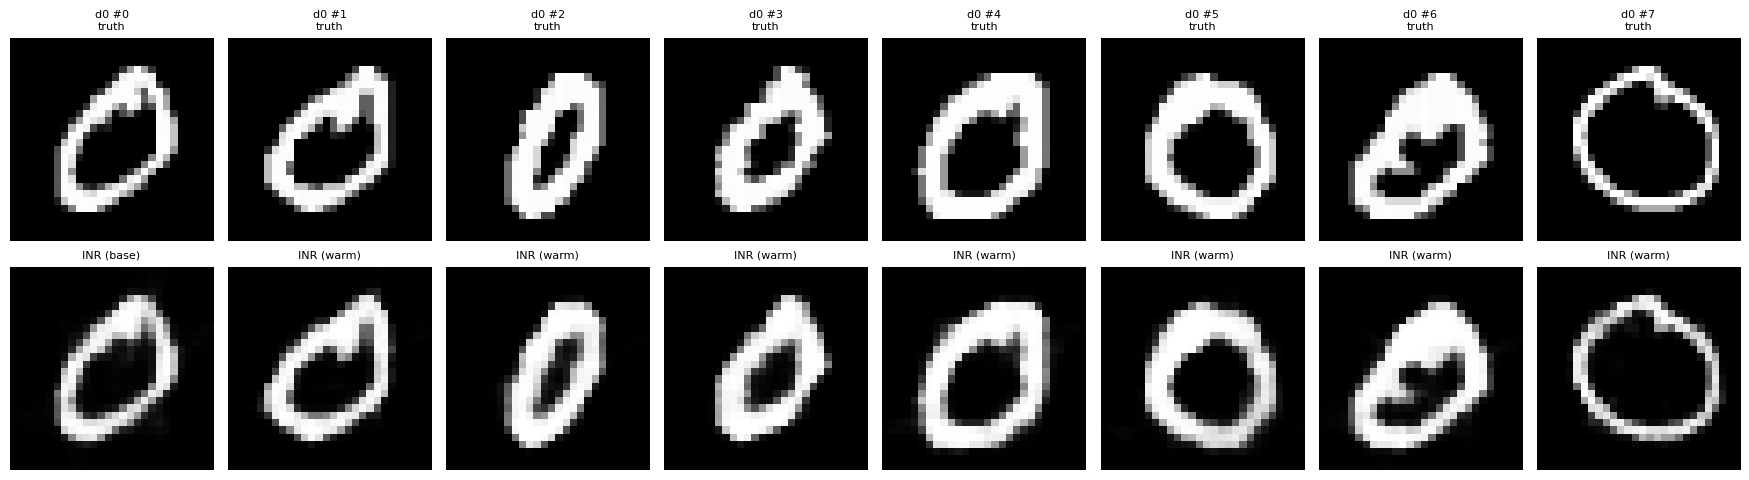

In [ ]:

import random

n_show = min(8, len(records))
shown = random.sample(records, n_show)

fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 5))
if n_show == 1:
    axes = axes.reshape(2, 1)

for col, record in enumerate(shown):
    target, label = dataset.get_target(record["position"])
    ground_truth = target.reshape(28, 28)

    model = load_inr(record["checkpoint"], device=device)
    prediction = reconstruct(model, coords, side=28, device=device)

    axes[0, col].imshow(ground_truth, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"d{record['digit']} #{record['index']}\ntruth", fontsize=8)
    axes[0, col].axis("off")

    axes[1, col].imshow(prediction, cmap="gray", vmin=0, vmax=1)
    tag = "base" if record["is_base"] else "warm"
    axes[1, col].set_title(f"INR ({tag})", fontsize=8)
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

## Scaling to all images

To train INRs for the entire MNIST training set, set `SAMPLES_PER_DIGIT = None`
and re-run. Notes:

- This is ~60k fits; use a CUDA device and expect it to take a while on CPU.
- Base INRs are cached, so interrupting and re-running re-uses them and only the
  per-image warm-start fits repeat (already-saved `sample_<i>.pth` files are
  overwritten deterministically, so it is safe to resume by lowering `DIGITS`).
- The `records` list is the manifest of every trained INR (digit, image index,
  dataset position, epochs, final loss, checkpoint path) and is what a downstream
  autoregressive "weights-as-tokens" model would consume.